In [1]:
import warnings
from pathlib import Path
 
import hdbscan
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
 
warnings.filterwarnings("ignore")

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [2]:
MEDIA_DIR = Path("media_tset")
MEDIA_DIR.mkdir(exist_ok=True)
 
CLUSTER_COLORS     = ["#3A7EBF", "#E07B39", "#3DAA6E", "#9B59B6", "#E74C3C"]
PLEIADES_PMRA_REF  =  19.99  # mas/yr, Gaia Collaboration 2023
PLEIADES_PMDEC_REF = -45.52  # mas/yr
 
plt.rcParams.update({
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.labelsize"   : 11,
    "axes.titlesize"   : 12,
})

# 1. QUERY DATA

In [3]:
adql = """
SELECT
    source_id, ra, dec,
    parallax, parallax_over_error,
    pmra, pmdec,
    phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE ra  BETWEEN 50 AND 75
  AND dec BETWEEN 15 AND 35
  AND parallax BETWEEN 4 AND 12
  AND parallax_over_error > 5
  AND pmra  IS NOT NULL
  AND pmdec IS NOT NULL
"""
# parallax 4-12 mas = jarak 83-250 pc, bracket kedua gugus target
 
print("Querying Gaia DR3 - Pleiades + Taurus region")
job = Gaia.launch_job_async(adql)
df  = job.get_results().to_pandas()
print(f"Raw query result : {len(df):,} stars")

Querying Gaia DR3 - Pleiades + Taurus region
INFO: Query finished. [astroquery.utils.tap.core]
Raw query result : 48,039 stars


In [4]:
print(df.describe())

          source_id            ra           dec      parallax  \
count  4.803900e+04  48039.000000  48039.000000  48039.000000   
mean   5.974467e+17     62.654057     24.889395      5.790279   
std    1.157137e+18      7.169402      5.663007      1.686482   
min    3.926515e+16     50.000508     15.000781      4.000012   
25%    6.522200e+16     56.557579     20.104996      4.481917   
50%    1.498954e+17     62.494104     24.702239      5.234850   
75%    1.704249e+17     68.908198     29.716776      6.683135   
max    3.420307e+18     74.999189     34.999477     11.997667   

       parallax_over_error          pmra         pmdec  phot_g_mean_mag  
count         48039.000000  48039.000000  48039.000000     47995.000000  
mean            101.065033     13.969253    -25.050865        16.554916  
std             120.139526     32.121447     30.828395         2.848780  
min               5.001040   -159.597971   -830.738754         2.197542  
25%              17.627070     -3.424474    

# 2. EDA


Basic Stats
          source_id            ra           dec      parallax  \
count  4.803900e+04  48039.000000  48039.000000  48039.000000   
mean   5.974467e+17     62.654057     24.889395      5.790279   
std    1.157137e+18      7.169402      5.663007      1.686482   
min    3.926515e+16     50.000508     15.000781      4.000012   
25%    6.522200e+16     56.557579     20.104996      4.481917   
50%    1.498954e+17     62.494104     24.702239      5.234850   
75%    1.704249e+17     68.908198     29.716776      6.683135   
max    3.420307e+18     74.999189     34.999477     11.997667   

       parallax_over_error          pmra         pmdec  phot_g_mean_mag  
count         48039.000000  48039.000000  48039.000000     47995.000000  
mean            101.065033     13.969253    -25.050865        16.554916  
std             120.139526     32.121447     30.828395         2.848780  
min               5.001040   -159.597971   -830.738754         2.197542  
25%              17.627070     

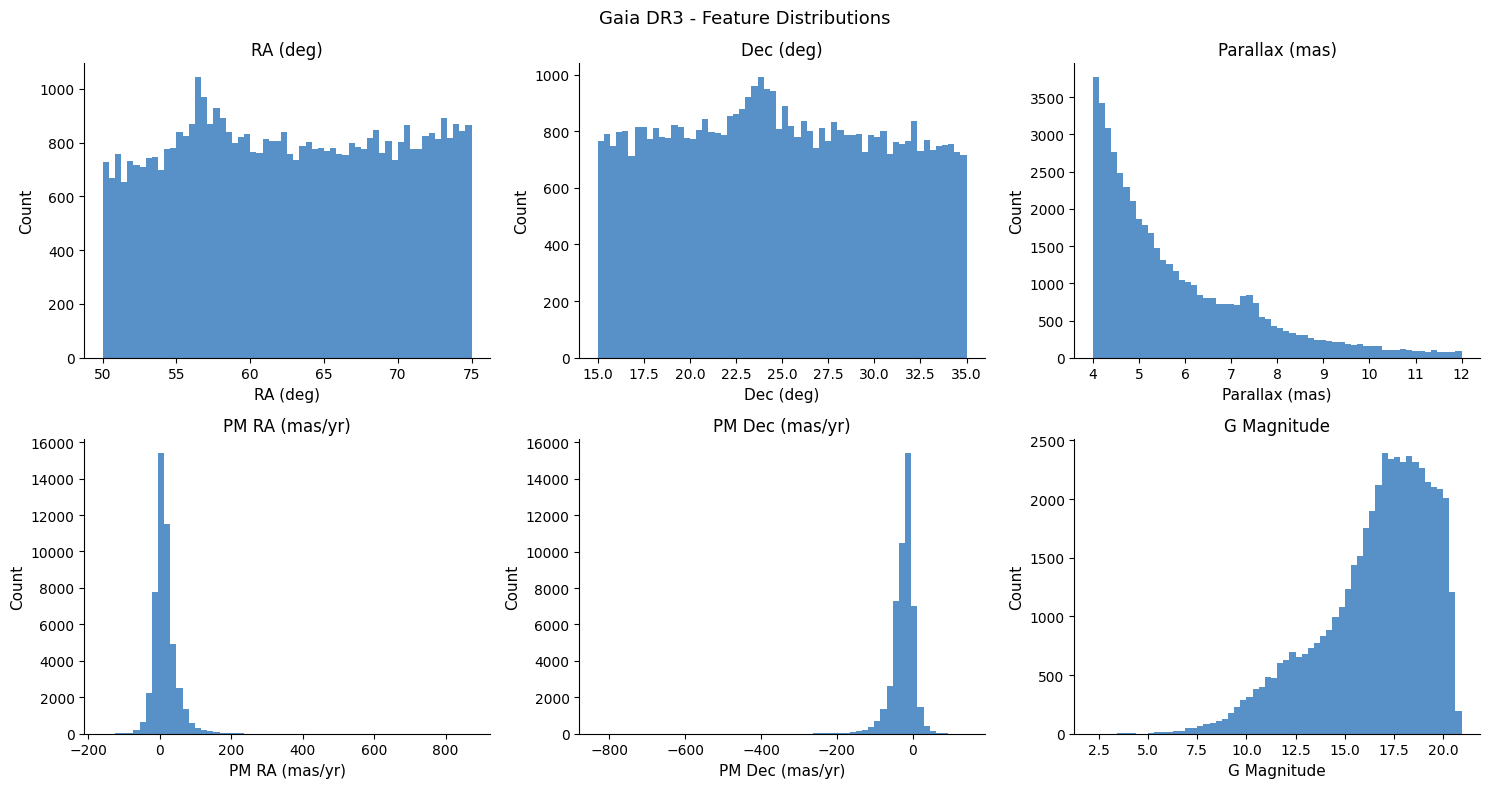

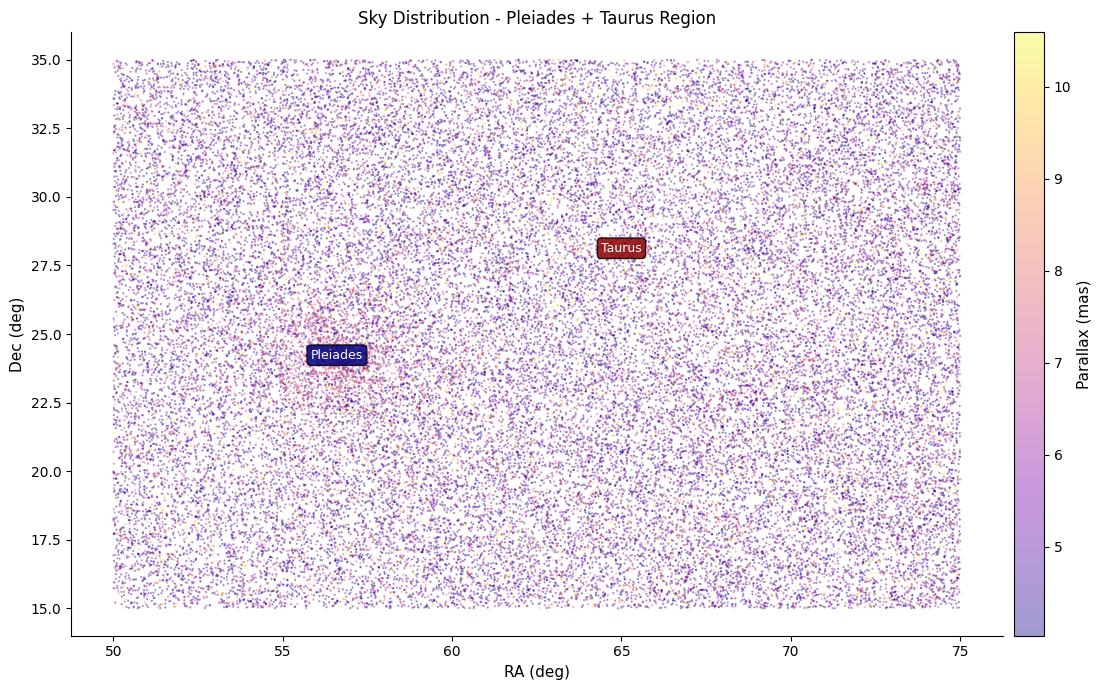

In [5]:
print("\nBasic Stats")
print(df.describe())
 
print("\nMissing Values")
print(df.isnull().sum())
 
# distribusi 6 fitur utama
cols   = ["ra", "dec", "parallax", "pmra", "pmdec", "phot_g_mean_mag"]
labels = ["RA (deg)", "Dec (deg)", "Parallax (mas)",
          "PM RA (mas/yr)", "PM Dec (mas/yr)", "G Magnitude"]
 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Gaia DR3 - Feature Distributions", fontsize=13)
 
for ax, col, label in zip(axes.flatten(), cols, labels):
    ax.hist(df[col].dropna(), bins=60, color="#3A7EBF", edgecolor="none", alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(label)
 
plt.tight_layout()
plt.savefig(MEDIA_DIR / "eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
 
# sky plot, warna = parallax
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(
    df["ra"], df["dec"], s=0.4, alpha=0.4,
    c=df["parallax"], cmap="plasma",
    vmin=df["parallax"].quantile(0.02),
    vmax=df["parallax"].quantile(0.98),
)
fig.colorbar(sc, ax=ax, label="Parallax (mas)", pad=0.01)
ax.annotate("Pleiades", xy=(56.6, 24.1), fontsize=9, color="white", ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="navy", alpha=0.85))
ax.annotate("Taurus", xy=(65.0, 28.0), fontsize=9, color="white", ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="darkred", alpha=0.85))
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title("Sky Distribution - Pleiades + Taurus Region")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "eda_sky.png", dpi=150, bbox_inches="tight")
plt.show()


# 3. PREPROCESSING

In [6]:
df_clean = df.dropna().copy()
print(f"After dropna          : {len(df_clean):,} stars  (removed {len(df) - len(df_clean):,})")
 
# filter outlier parallax 3-sigma
mu, sigma = df_clean["parallax"].mean(), df_clean["parallax"].std()
df_clean  = df_clean[np.abs(df_clean["parallax"] - mu) < 3 * sigma].reset_index(drop=True)
print(f"After outlier removal : {len(df_clean):,} stars  (removed {len(df) - len(df_clean):,} total)")


After dropna          : 47,995 stars  (removed 44)
After outlier removal : 47,242 stars  (removed 797 total)


# 4. KOORDINAT TRANSFORM -> Cartesian (parsec)


In [7]:
dist    = 1000.0 / df_clean["parallax"]
ra_rad  = np.radians(df_clean["ra"])
dec_rad = np.radians(df_clean["dec"])
 
df_clean["x"] = dist * np.cos(dec_rad) * np.cos(ra_rad)
df_clean["y"] = dist * np.cos(dec_rad) * np.sin(ra_rad)
df_clean["z"] = dist * np.sin(dec_rad)
 
print("3D Coordinate Stats (parsec)")
print(df_clean[["x", "y", "z"]].describe())

3D Coordinate Stats (parsec)
                  x             y             z
count  47242.000000  47242.000000  47242.000000
mean      76.630953    148.380278     78.234585
std       25.851845     35.916824     25.069429
min       20.234625     59.933616     24.212390
25%       57.015132    119.759626     58.720297
50%       73.139108    151.496476     75.370513
75%       94.729374    176.657663     96.330550
max      153.282996    231.450539    142.940390


# 5. FEATURE CONSTRUCTION & SCALING

In [ ]:
features = ["x", "y", "z", "pmra", "pmdec"]
X        = df_clean[features].values
X_scaled = RobustScaler().fit_transform(X)

print("Sebelum RobustScaler")
print(f"max: {X.max()} \nmin: {X.min()} \nvar: {X.var()}")

print("\nSetelah RobustScaler")
print(f"max: {X_scaled.max()} \nmin: {X_scaled.min()} \nvar: {X_scaled.var()}")

Sebelum RobustScaler
max: 872.4843319238057 
min: -830.7387538949012 
var: 4438.916109812055

Setelah RobustScaler
max: 30.151415316278474 
min: -26.359327635703053 
var: 0.706832256246441


# 6. HDBSCAN Clustering

In [9]:
print("Running HDBSCAN")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size         = 80,
    min_samples              = 15,
    cluster_selection_epsilon= 0.3,
    metric                   = "euclidean",
    cluster_selection_method = "eom",  # EOM lebih stabil dari 'leaf' untuk densitas bervariasi
)
labels = clusterer.fit_predict(X_scaled)
df_clean["cluster"] = labels
 
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = int((labels == -1).sum())
noise_pct  = n_noise / len(labels) * 100
 
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,} ({noise_pct:.1f}%)")
print("\nCluster sizes:")
print(pd.Series(labels[labels != -1]).value_counts())

Running HDBSCAN
Clusters found : 2
Noise points   : 42,354 (89.7%)

Cluster sizes:
1    2874
0    2014
Name: count, dtype: int64


# 7. EVALUASI

In [10]:
mask = labels != -1
if mask.sum() > 1 and n_clusters > 1:
    sil = silhouette_score(X_scaled[mask], labels[mask],
                           sample_size=min(10_000, int(mask.sum())))
    print(f"\nSilhouette Score : {sil:.4f}")
 
# cluster summary table
cluster_df = df_clean[df_clean["cluster"] != -1]
summary = cluster_df.groupby("cluster").agg(
    n_stars      = ("cluster",         "count"),
    mean_ra      = ("ra",              "mean"),
    mean_dec     = ("dec",             "mean"),
    mean_plx_mas = ("parallax",        "mean"),
    mean_dist_pc = ("parallax",        lambda p: round(1000 / p.mean(), 1)),
    mean_pmra    = ("pmra",            "mean"),
    mean_pmdec   = ("pmdec",           "mean"),
    mean_gmag    = ("phot_g_mean_mag", "mean"),
).sort_values("n_stars", ascending=False)
 
print("\nCluster Summary\n")
print(summary.to_string(float_format="{:.2f}".format))
print()
 
# auto-label berdasarkan posisi sky
for cid, row in summary.iterrows():
    d_pleiades = np.sqrt((row["mean_ra"] - 56.6)**2 + (row["mean_dec"] - 24.1)**2)
    d_taurus   = np.sqrt((row["mean_ra"] - 65.0)**2 + (row["mean_dec"] - 28.0)**2)
    if d_pleiades < 3:
        print(f"Cluster {cid} -> kemungkinan PLEIADES (n={row['n_stars']}, dist={row['mean_dist_pc']} pc)")
    if d_taurus < 5:
        print(f"Cluster {cid} -> kemungkinan TAURUS OB (n={row['n_stars']}, dist={row['mean_dist_pc']} pc)")


Silhouette Score : 0.4163

Cluster Summary

         n_stars  mean_ra  mean_dec  mean_plx_mas  mean_dist_pc  mean_pmra  mean_pmdec  mean_gmag
cluster                                                                                          
1           2874    66.95     25.31          5.38        185.90       3.25      -10.43      16.87
0           2014    57.72     24.72          7.08        141.20      19.37      -42.69      15.49

Cluster 1 -> kemungkinan TAURUS OB (n=2874.0, dist=185.9 pc)
Cluster 0 -> kemungkinan PLEIADES (n=2014.0, dist=141.2 pc)


# 8. VISUALISASI

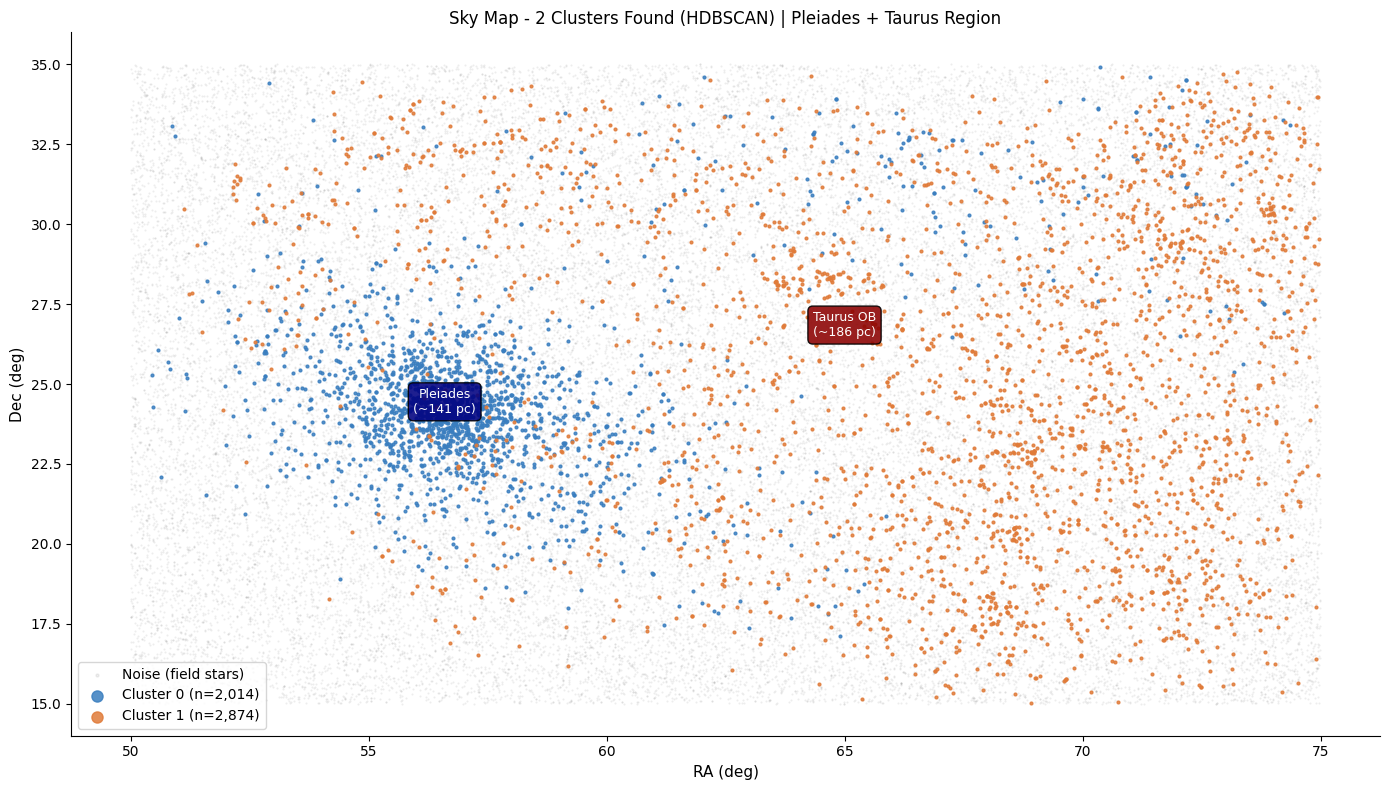

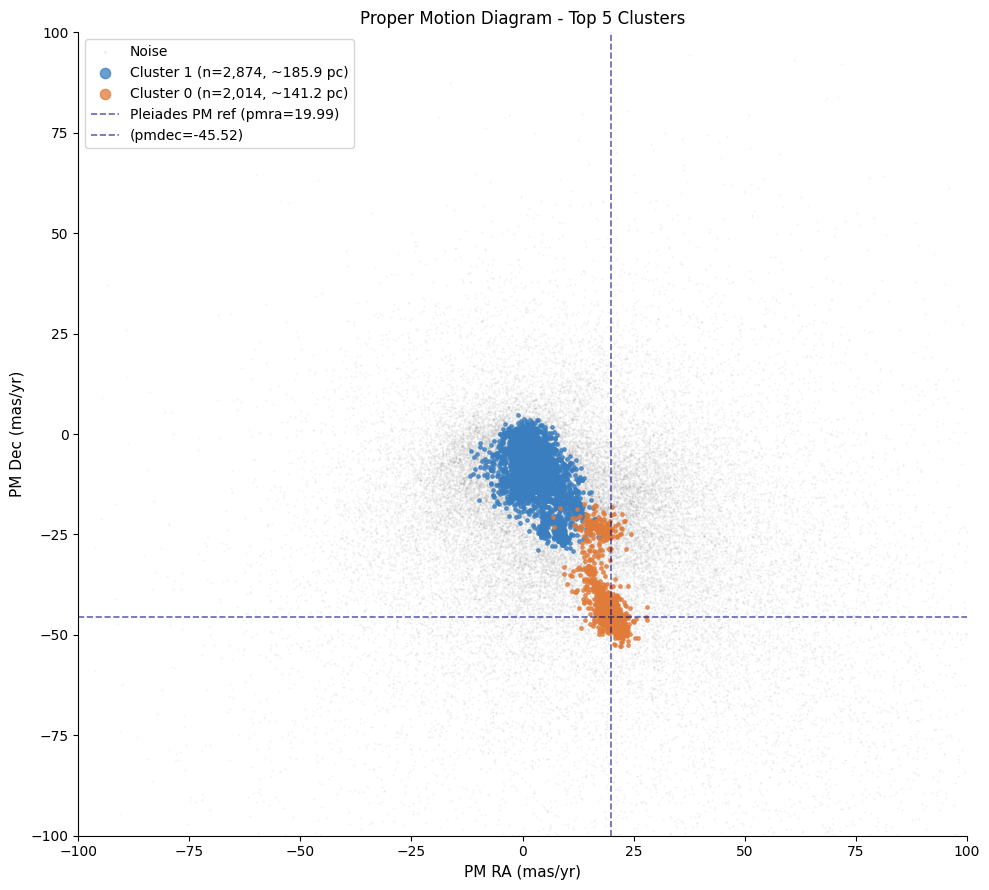

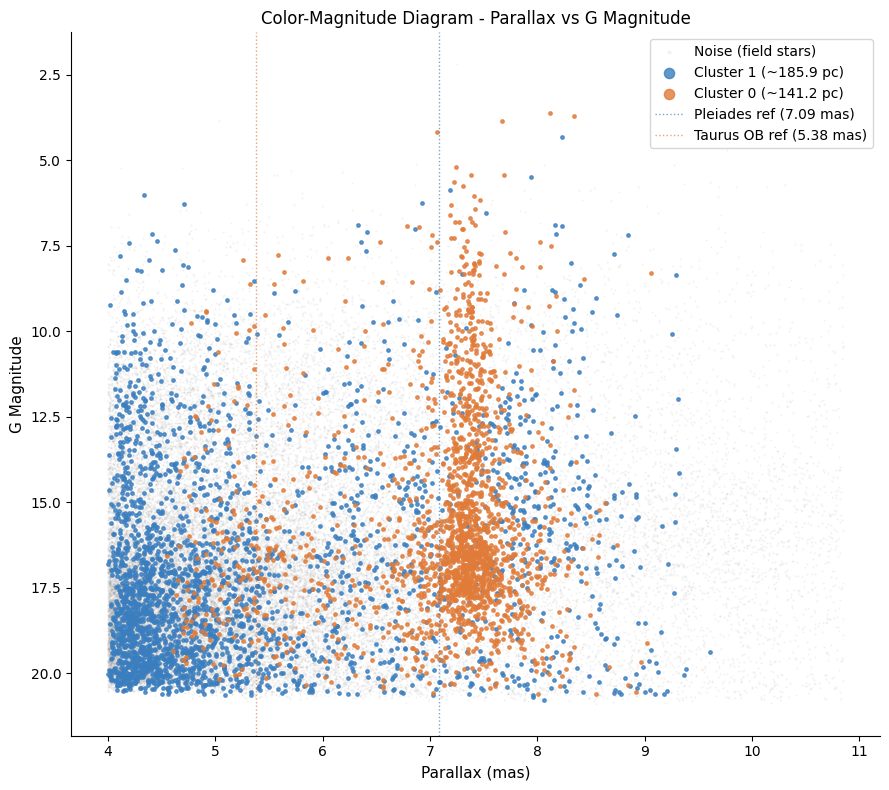

In [ ]:
noise_mask = df_clean["cluster"] == -1
 
# sky map
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(df_clean.loc[noise_mask, "ra"], df_clean.loc[noise_mask, "dec"],
           s=0.3, alpha=0.12, c="gray", label="Noise (field stars)")
 
for i, cid in enumerate(sorted(df_clean.loc[~noise_mask, "cluster"].unique())):
    m = df_clean["cluster"] == cid
    ax.scatter(df_clean.loc[m, "ra"], df_clean.loc[m, "dec"],
               s=4, alpha=0.85, c=CLUSTER_COLORS[i % len(CLUSTER_COLORS)],
               label=f"Cluster {cid} (n={m.sum():,})")
 
ax.annotate("Pleiades\n(~141 pc)", xy=(56.6, 24.1), fontsize=9,
            color="white", ha="center",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="navy", alpha=0.88))
ax.annotate("Taurus OB\n(~186 pc)", xy=(65.0, 26.5), fontsize=9,
            color="white", ha="center",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="darkred", alpha=0.88))
 
ax.set_xlabel("RA (deg)")
ax.set_ylabel("Dec (deg)")
ax.set_title(f"Sky Map - {n_clusters} Clusters Found (HDBSCAN) | Pleiades + Taurus Region")
ax.legend(markerscale=4, loc="lower left")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "clusters_sky.png", dpi=150, bbox_inches="tight")
plt.show()
 
# 3D interactive
# sample sekali
n_sample  = min(50_000, len(df_clean))
df_sample = df_clean.sample(n_sample, random_state=42)
 
fig_3d = px.scatter_3d(
    df_sample, x="x", y="y", z="z",
    color=df_sample["cluster"].astype(str),
    opacity=0.5,
    title="3D Star Distribution - Pleiades + Taurus (Parsec Space)",
    labels={"x": "X (pc)", "y": "Y (pc)", "z": "Z (pc)", "color": "Cluster"},
    color_discrete_sequence=px.colors.qualitative.Alphabet,
)
fig_3d.update_traces(marker=dict(size=1.5))
fig_3d.write_html(str(MEDIA_DIR / "clusters_3d.html"))
fig_3d.show()
 
# proper motion diagram
fig, ax = plt.subplots(figsize=(10, 9))
ax.scatter(df_clean.loc[noise_mask, "pmra"], df_clean.loc[noise_mask, "pmdec"],
           s=0.3, alpha=0.08, c="gray", label="Noise")
 
for i, cid in enumerate(summary.head(5).index):
    m    = df_clean["cluster"] == cid
    dist = summary.loc[cid, "mean_dist_pc"]
    ax.scatter(df_clean.loc[m, "pmra"], df_clean.loc[m, "pmdec"],
               s=6, alpha=0.75, c=CLUSTER_COLORS[i % len(CLUSTER_COLORS)],
               label=f"Cluster {cid} (n={m.sum():,}, ~{dist} pc)")
 
ax.axvline(PLEIADES_PMRA_REF,  color="navy", lw=1.2, ls="--", alpha=0.6,
           label=f"Pleiades PM ref (pmra={PLEIADES_PMRA_REF})")
ax.axhline(PLEIADES_PMDEC_REF, color="navy", lw=1.2, ls="--", alpha=0.6,
           label=f"(pmdec={PLEIADES_PMDEC_REF})")
 
ax.set_xlabel("PM RA (mas/yr)")
ax.set_ylabel("PM Dec (mas/yr)")
ax.set_title("Proper Motion Diagram - Top 5 Clusters")
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.legend(markerscale=3, loc="upper left")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "clusters_pm.png", dpi=150, bbox_inches="tight")
plt.show()
 
# CMD: parallax vs G magnitude
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(df_clean.loc[noise_mask, "parallax"], df_clean.loc[noise_mask, "phot_g_mean_mag"],
           s=0.4, alpha=0.08, c="gray", label="Noise (field stars)")
 
for i, cid in enumerate(summary.index):
    m    = df_clean["cluster"] == cid
    dist = summary.loc[cid, "mean_dist_pc"]
    ax.scatter(df_clean.loc[m, "parallax"], df_clean.loc[m, "phot_g_mean_mag"],
               s=6, alpha=0.8, c=CLUSTER_COLORS[i % len(CLUSTER_COLORS)],
               label=f"Cluster {cid} (~{dist} pc)")
 
ax.axvline(1000 / 141.1, color=CLUSTER_COLORS[0], lw=1, ls=":", alpha=0.7,
           label="Pleiades ref (7.09 mas)")
ax.axvline(1000 / 185.9, color=CLUSTER_COLORS[1], lw=1, ls=":", alpha=0.7,
           label="Taurus OB ref (5.38 mas)")
 
ax.invert_yaxis()
ax.set_xlabel("Parallax (mas)")
ax.set_ylabel("G Magnitude")
ax.set_title("Color-Magnitude Diagram - Parallax vs G Magnitude")
ax.legend(markerscale=3, loc="upper right")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "cmd.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
print("Kesimpulan\n")
print(f"Stars processed  : {len(df_clean):,}")
print(f"Clusters found   : {n_clusters}")
print(f"Noise            : {n_noise:,} ({noise_pct:.1f}%)")

Kesimpulan

Stars processed  : 47,242
Clusters found   : 2
Noise            : 42,354 (89.7%)
